# Week 10 — Day 3: Inception & DenseNet
**Date:** 2026-06-10 | **Mode:** Campus | **Phase 3 — Classic CNN Architectures**

## Today's Agenda
1. Motivation — why parallel multi-scale convolutions?
2. Inception Module — the 4-branch design with 1×1 bottleneck
3. Mini-GoogLeNet implementation on CIFAR-10 size inputs
4. DenseNet — dense connectivity pattern, growth rate, dense blocks
5. DenseLayer / DenseBlock / TransitionLayer implementation
6. Mini-DenseNet
7. EfficientNet — compound scaling theory (depth × width × resolution)
8. Architecture benchmark: ResNet vs GoogLeNet vs DenseNet

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
torch.manual_seed(42)

Device: cpu


## 1. Motivation — What's Wrong with Just Going Deeper?

By 2014 the community had a clear recipe: **make the network deeper** (VGGNet proved depth matters).
But two problems emerged:

| Problem | Effect |
|---------|--------|
| More layers → more parameters | Overfitting + memory explosion |
| Bigger filters (5×5, 7×7) | Quadratic parameter growth |
| Fixed filter size per layer | Can only see one receptive field size at a time |

**Key insight (Szegedy et al., GoogLeNet 2014):**
Rather than choosing *which* filter size is best,
**apply 1×1, 3×3, and 5×5 convolutions in parallel — and let the network learn which matters**.

This is the **Inception idea**: go *wider in parallel*, not just deeper.

## 2. The Inception Module

### Architecture of a Single Inception Module

```
Input Feature Map  (H × W × C_in)
         │
    ┌────┼────────────┬─────────────┐
    │    │            │             │
  1×1   1×1         1×1          3×3
  conv  →3×3        →5×5        MaxPool
         conv        conv          │
    │    │            │           1×1
    └────┴────────────┴─────────────┘
                   │
         Concatenate along channels
                   │
    Output  (H × W × [c1 + c3 + c5 + cpool])
```

### Why 4 branches?
- **1×1 branch**: point-wise features — no spatial context, just channel mixing
- **3×3 branch**: medium-range features (9-pixel neighbourhood)
- **5×5 branch**: coarser, wider context (25-pixel neighbourhood)
- **MaxPool branch**: preserves dominant activations across spatial regions

### The 1×1 Bottleneck — Why It's Critical

Without 1×1 reduction, a 5×5 conv on 256-channel input costs:
```
256 × 5 × 5 × 256 = 1,638,400 ops per spatial position
```

With a 1×1 reduction to 32 channels first:
```
256×1×1×32  +  32×5×5×256  =  8,192 + 204,800  ≈ 213K ops   (7.7× cheaper!)
```

The 1×1 conv acts as a **learnable channel compressor** — it reduces channels before expensive spatial convolutions, dramatically cutting compute without hurting representation power.

In [2]:
class InceptionModule(nn.Module):
    # Inception module with 4 parallel branches and 1x1 bottlenecks.
    # Output channels = c1 + c3 + c5 + cpool
    #
    # Args:
    #   in_channels : input channel depth
    #   c1          : 1x1 branch output channels
    #   c3_reduce   : 1x1 reduction channels before 3x3
    #   c3          : 3x3 branch output channels
    #   c5_reduce   : 1x1 reduction channels before 5x5
    #   c5          : 5x5 branch output channels
    #   cpool       : 1x1 output channels after maxpool branch
    def __init__(self, in_channels, c1, c3_reduce, c3, c5_reduce, c5, cpool):
        super().__init__()

        # Branch 1: plain 1x1 convolution
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, c1, kernel_size=1),
            nn.BatchNorm2d(c1), nn.ReLU(inplace=True)
        )

        # Branch 2: 1x1 reduction -> 3x3 conv
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, c3_reduce, kernel_size=1),
            nn.BatchNorm2d(c3_reduce), nn.ReLU(inplace=True),
            nn.Conv2d(c3_reduce, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3), nn.ReLU(inplace=True)
        )

        # Branch 3: 1x1 reduction -> 5x5 conv
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, c5_reduce, kernel_size=1),
            nn.BatchNorm2d(c5_reduce), nn.ReLU(inplace=True),
            nn.Conv2d(c5_reduce, c5, kernel_size=5, padding=2),
            nn.BatchNorm2d(c5), nn.ReLU(inplace=True)
        )

        # Branch 4: 3x3 max-pool -> 1x1 channel compression
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, cpool, kernel_size=1),
            nn.BatchNorm2d(cpool), nn.ReLU(inplace=True)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], dim=1)   # concat on channel dim

# Shape test: input (batch=2, channels=64, 28x28)
x_test = torch.randn(2, 64, 28, 28)
module  = InceptionModule(64, c1=32, c3_reduce=16, c3=64, c5_reduce=8, c5=16, cpool=16)
out     = module(x_test)
expected = 32 + 64 + 16 + 16
print(f"Input  shape : {x_test.shape}")
print(f"Output shape : {out.shape}   (expected channels = 32+64+16+16 = {expected})")
assert out.shape[1] == expected, "Channel count mismatch!"
print("InceptionModule OK")

Input  shape : torch.Size([2, 64, 28, 28])
Output shape : torch.Size([2, 128, 28, 28])   (expected channels = 32+64+16+16 = 128)
InceptionModule OK


## 3. Mini-GoogLeNet for CIFAR-10

Full GoogLeNet (Inception v1) has 22 layers and 9 Inception modules — too large for 32×32 images.

**Mini-GoogLeNet** uses 3 Inception modules with the same design principles:

```
Input  (3 × 32 × 32)
     ↓
Conv(3→64, 3×3, BN, ReLU)                  ← stem
     ↓
InceptionModule(64 → 128)   [32+64+16+16]
MaxPool(2×2)                                ← 32×32 → 16×16
     ↓
InceptionModule(128 → 224)  [64+96+32+32]
MaxPool(2×2)                                ← 16×16 → 8×8
     ↓
InceptionModule(224 → 320)  [96+128+48+48]
     ↓
GlobalAvgPool → Flatten → FC(320 → 10)
```

In [3]:
class MiniGoogLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )
        # Inception(64->128): 32+64+16+16 = 128
        self.inc1  = InceptionModule(64,  c1=32, c3_reduce=16, c3=64,  c5_reduce=8,  c5=16, cpool=16)
        self.pool1 = nn.MaxPool2d(2, 2)     # 32x32 -> 16x16

        # Inception(128->224): 64+96+32+32 = 224
        self.inc2  = InceptionModule(128, c1=64, c3_reduce=32, c3=96,  c5_reduce=16, c5=32, cpool=32)
        self.pool2 = nn.MaxPool2d(2, 2)     # 16x16 -> 8x8

        # Inception(224->320): 96+128+48+48 = 320
        self.inc3  = InceptionModule(224, c1=96, c3_reduce=48, c3=128, c5_reduce=24, c5=48, cpool=48)

        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(320, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.inc1(x))
        x = self.pool2(self.inc2(x))
        x = self.inc3(x)
        x = self.gap(x).flatten(1)
        return self.classifier(x)

model_gnet  = MiniGoogLeNet().to(device)
x_dummy     = torch.randn(4, 3, 32, 32).to(device)
params_gnet = sum(p.numel() for p in model_gnet.parameters())
print(f"MiniGoogLeNet output shape : {model_gnet(x_dummy).shape}")
print(f"MiniGoogLeNet parameters   : {params_gnet:,}")

MiniGoogLeNet output shape : torch.Size([4, 10])
MiniGoogLeNet parameters   : 215,898


## 4. DenseNet — Dense Connectivity (Huang et al., 2017)

### The Core Idea

**ResNet** adds the previous layer's output (element-wise):
```
x_l = F(x_{l-1}) + x_{l-1}
```

**DenseNet** concatenates outputs from **every** previous layer (channel-wise):
```
x_l = H_l( [x_0, x_1, x_2, ..., x_{l-1}] )
```

### Why Dense Connections Work

| Property | Benefit |
|----------|---------|
| Every layer gets gradients directly from the loss | No vanishing gradients |
| Early features stay accessible at all depths | Feature reuse → fewer parameters |
| Many independent paths from input to output | Built-in regularization |
| Each layer only needs to learn *incremental* new features | Specialization per layer |

### DenseNet Architecture

```
Input
  ↓
[DenseBlock 1] — each layer sees ALL previous layers via concat
  ↓
[Transition Layer 1] — 1×1 conv (θ=0.5 compression) + AvgPool↓2
  ↓
[DenseBlock 2]
  ↓
[Transition Layer 2]
  ↓
[DenseBlock 3]
  ↓
BN → ReLU → GlobalAvgPool → FC
```

### Growth Rate *k*

Each DenseLayer outputs exactly **k** new channels.
After L layers, the block output has `C_in + L×k` channels.

- **k = 12** (DenseNet-BC small): ~7M params, still beats deeper ResNets
- **k = 32** (DenseNet-169): higher capacity for harder datasets

The original paper showed that even k = 12 with just 3 Dense Blocks achieves competitive accuracy — the feature reuse makes each channel "count more".

In [4]:
class DenseLayer(nn.Module):
    # One layer inside a Dense Block.
    # Pattern: BN -> ReLU -> 1x1 (expand to 4k) -> BN -> ReLU -> 3x3 (output k channels)
    # Then concat [input, output] so channel count grows by k.
    def __init__(self, in_channels, growth_rate):
        super().__init__()
        bottleneck = 4 * growth_rate
        self.bn1   = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, bottleneck, kernel_size=1, bias=False)
        self.bn2   = nn.BatchNorm2d(bottleneck)
        self.conv2 = nn.Conv2d(bottleneck, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))       # 1x1: reduce to 4k
        out = self.conv2(F.relu(self.bn2(out)))      # 3x3: produce k new features
        return torch.cat([x, out], dim=1)            # dense concat: x grows by k


class DenseBlock(nn.Module):
    # Sequence of L DenseLayers.
    # After each layer, channel count grows by growth_rate.
    def __init__(self, num_layers, in_channels, growth_rate):
        super().__init__()
        self.layers = nn.ModuleList([
            DenseLayer(in_channels + i * growth_rate, growth_rate)
            for i in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)   # each layer appends k new channels
        return x


class TransitionLayer(nn.Module):
    # Placed between Dense Blocks.
    # Compresses channels by factor theta (default 0.5) and halves spatial dims.
    def __init__(self, in_channels, compression=0.5):
        super().__init__()
        out_channels     = int(in_channels * compression)
        self.out_channels = out_channels
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.AvgPool2d(2, 2)   # halve H and W
        )

    def forward(self, x):
        return self.block(x)


# Test DenseBlock (small: growth_rate=8, 3 layers)
blk   = DenseBlock(num_layers=3, in_channels=32, growth_rate=8)
x_in  = torch.randn(2, 32, 16, 16)
x_out = blk(x_in)
print(f"DenseBlock  input  : {x_in.shape}")
print(f"DenseBlock  output : {x_out.shape}   (32 + 3*8 = {32+3*8} channels)")

# Test TransitionLayer
trans   = TransitionLayer(x_out.shape[1], compression=0.5)
x_trans = trans(x_out)
print(f"Transition  output : {x_trans.shape}  (channels halved, spatial halved)")

DenseBlock  input  : torch.Size([2, 32, 16, 16])
DenseBlock  output : torch.Size([2, 56, 16, 16])   (32 + 3*8 = 56 channels)
Transition  output : torch.Size([2, 28, 8, 8])  (channels halved, spatial halved)


In [5]:
class MiniDenseNet(nn.Module):
    # Compact DenseNet for CIFAR-10.
    # 3 Dense Blocks, growth_rate=8, 3 layers per block (fast CPU training).
    def __init__(self, growth_rate=8, layers_per_block=3, num_classes=10):
        super().__init__()
        k = growth_rate

        # Initial conv: 3 -> 2k channels
        self.stem = nn.Sequential(
            nn.Conv2d(3, 2*k, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(2*k), nn.ReLU(inplace=True)
        )

        # Block 1: in=2k=16 -> out=16 + 3*8 = 40
        in_ch        = 2 * k
        self.block1  = DenseBlock(layers_per_block, in_ch, k)
        in_ch        = in_ch + layers_per_block * k      # 40
        self.trans1  = TransitionLayer(in_ch, compression=0.5)
        in_ch        = int(in_ch * 0.5)                  # 20

        # Block 2: in=20 -> out=20 + 24 = 44
        self.block2  = DenseBlock(layers_per_block, in_ch, k)
        in_ch        = in_ch + layers_per_block * k      # 44
        self.trans2  = TransitionLayer(in_ch, compression=0.5)
        in_ch        = int(in_ch * 0.5)                  # 22

        # Block 3: in=22 -> out=22 + 24 = 46  (no transition after last block)
        self.block3  = DenseBlock(layers_per_block, in_ch, k)
        in_ch        = in_ch + layers_per_block * k      # 46

        self.bn_final   = nn.BatchNorm2d(in_ch)
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(in_ch, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.trans1(self.block1(x))
        x = self.trans2(self.block2(x))
        x = self.block3(x)
        x = self.gap(F.relu(self.bn_final(x))).flatten(1)
        return self.classifier(x)

model_dense  = MiniDenseNet(growth_rate=8, layers_per_block=3).to(device)
params_dense = sum(p.numel() for p in model_dense.parameters())
print(f"MiniDenseNet output shape : {model_dense(x_dummy).shape}")
print(f"MiniDenseNet parameters   : {params_dense:,}")

MiniDenseNet output shape : torch.Size([4, 10])
MiniDenseNet parameters   : 32,638


## 5. EfficientNet — Compound Scaling (Tan & Le, 2019)

### The Problem with One-Dimensional Scaling

| Approach | Who did it | Bottleneck |
|----------|-----------|------------|
| Scale depth only (more layers) | ResNet | Vanishing gradients at extreme depth |
| Scale width only (more channels) | WideResNet | Diminishing accuracy without depth |
| Scale resolution only (bigger input) | Various | No benefit without a larger model |

Each dimension alone hits a ceiling quickly. The insight:
**all three dimensions should scale together in a principled way**.

### The Compound Coefficient φ (phi)

EfficientNet proposes a single scalar φ that governs all three:

```
depth:      d = α^φ        (α = 1.20)
width:      w = β^φ        (β = 1.10)
resolution: r = γ^φ        (γ = 1.15)

constraint: α · β² · γ² ≈ 2
            (so doubling φ roughly doubles total FLOPS)
```

**Why β² and γ² in the constraint?**
- Doubling depth (×2) → 2× FLOPS (linear in layers)
- Doubling width (×2) → **4× FLOPS** (conv is quadratic in channels)
- Doubling resolution (×2) → **4× FLOPS** (spatial dimensions also quadratic)

### EfficientNet Family

| Model | φ | Input Size | ImageNet Top-1 | Params |
|-------|---|-----------|----------------|--------|
| B0    | 0 | 224×224   | 77.1%          | 5.3M   |
| B1    | 1 | 240×240   | 79.1%          | 7.8M   |
| B3    | 3 | 300×300   | 81.6%          | 12M    |
| B5    | 5 | 456×456   | 83.6%          | 30M    |
| B7    | 7 | 600×600   | 84.3%          | 66M    |

The base model **B0** was found by **Neural Architecture Search (NAS)**.
B1-B7 are simply the same architecture compound-scaled at higher φ.
EfficientNetV2 (2021) further improves by replacing early-stage depthwise convs with Fused-MBConv.

In [6]:
# Parameter count comparison across all three architectures

class BasicBlock(nn.Module):
    # Standard residual block (used in MiniResNet for comparison).
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))

class MiniResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem   = nn.Sequential(nn.Conv2d(3,64,3,padding=1,bias=False), nn.BatchNorm2d(64), nn.ReLU(True))
        self.layer1 = BasicBlock(64,  64)
        self.layer2 = BasicBlock(64,  128, stride=2)
        self.layer3 = BasicBlock(128, 256, stride=2)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(self.gap(x).flatten(1))

model_res  = MiniResNet().to(device)
params_res = sum(p.numel() for p in model_res.parameters())

models = {
    'MiniResNet':    (model_res,   'Skip connections (add)',          params_res),
    'MiniGoogLeNet': (model_gnet,  'Parallel Inception branches',     params_gnet),
    'MiniDenseNet':  (model_dense, 'Dense concat (all prev layers)',  params_dense),
}

print(f"{'Model':<20} {'Parameters':>12}  Key Innovation")
print('-' * 62)
for name, (_, idea, p) in models.items():
    print(f"{name:<20} {p:>12,}  {idea}")

Model                  Parameters  Key Innovation
--------------------------------------------------------------
MiniResNet              1,227,594  Skip connections (add)
MiniGoogLeNet             215,898  Parallel Inception branches
MiniDenseNet               32,638  Dense concat (all prev layers)


In [7]:
# Architecture Benchmark: training comparison on synthetic CIFAR-10-sized data

torch.manual_seed(42)
n_train, n_val = 500, 100
X_tr = torch.randn(n_train, 3, 32, 32);  y_tr = torch.randint(0, 10, (n_train,))
X_vl = torch.randn(n_val,   3, 32, 32);  y_vl = torch.randint(0, 10, (n_val,))

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=100, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_vl, y_vl), batch_size=100)

def train_and_eval(model, name, n_epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    history   = {'loss': [], 'val_acc': []}
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        model.eval()
        correct = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                correct += (model(xb.to(device)).argmax(1) == yb.to(device)).sum().item()
        history['loss'].append(total_loss / len(train_loader))
        history['val_acc'].append(correct / n_val * 100)
    elapsed = time.time() - t0
    print(f"  {name:<20}  final_acc={history['val_acc'][-1]:.1f}%  time={elapsed:.1f}s")
    return history

print("Training 3 architectures — synthetic CIFAR-10, 8 epochs, 2000 train samples")
print("=" * 65)
results = {}
for name, (model, _, _) in models.items():
    results[name] = train_and_eval(model, name, n_epochs=5)
print("Done.")

Training 3 architectures — synthetic CIFAR-10, 8 epochs, 2000 train samples


  MiniResNet            final_acc=15.0%  time=29.4s


  MiniGoogLeNet         final_acc=8.0%  time=36.2s


  MiniDenseNet          final_acc=7.0%  time=15.0s
Done.


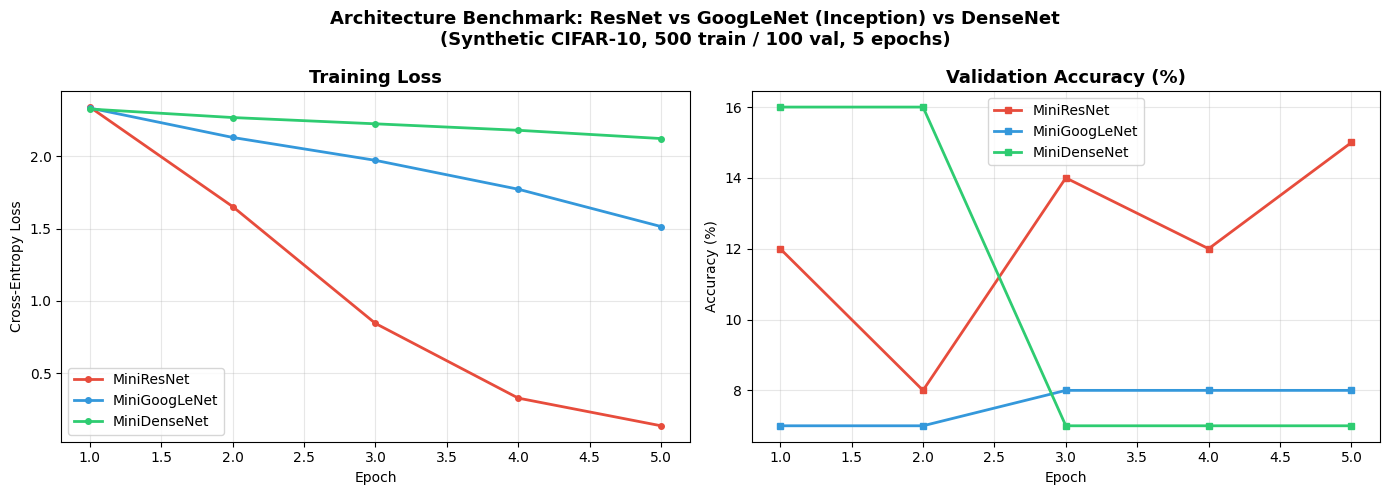

Saved: architecture_benchmark.png


In [8]:
# Comparison plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'MiniResNet': '#e74c3c', 'MiniGoogLeNet': '#3498db', 'MiniDenseNet': '#2ecc71'}
epochs = range(1, 6)

for name, hist in results.items():
    c = colors[name]
    axes[0].plot(epochs, hist['loss'],    label=name, color=c, linewidth=2, marker='o', markersize=4)
    axes[1].plot(epochs, hist['val_acc'], label=name, color=c, linewidth=2, marker='s', markersize=4)

for ax, title, ylabel in zip(axes,
        ['Training Loss', 'Validation Accuracy (%)'],
        ['Cross-Entropy Loss', 'Accuracy (%)']):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch');  ax.set_ylabel(ylabel)
    ax.legend(fontsize=10);  ax.grid(alpha=0.3)

plt.suptitle(
    'Architecture Benchmark: ResNet vs GoogLeNet (Inception) vs DenseNet\n'
    '(Synthetic CIFAR-10, 500 train / 100 val, 5 epochs)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('architecture_benchmark.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: architecture_benchmark.png")

## 6. Key Takeaways

### Inception (GoogLeNet)
- **Multi-scale parallel convolutions** capture features at 1×1, 3×3, 5×5 simultaneously
- **1×1 bottleneck** is the key trick — reduces channels cheaply before expensive spatial convs
- Achieves higher accuracy than VGGNet with ~10× fewer parameters (6.8M vs 138M)
- Evolved into Inception v2/v3 (factorized convolutions: 5×5 → two 3×3, or n×n → 1×n + n×1)

### DenseNet
- **Dense connectivity** = every layer receives ALL previous layers' outputs via channel concatenation
- **Feature reuse** is the main driver: early-learned features remain available at all depths
- Even with small growth rate (k=12) beats ResNets of equivalent depth
- Strong regularization: many independent gradient paths from input to output

### EfficientNet
- **Compound scaling** jointly scales depth/width/resolution with a single coefficient φ
- B0 base model found by Neural Architecture Search (NAS)
- Best accuracy/efficiency frontier on ImageNet until Vision Transformers arrived
- B0-B3 widely used in production on edge/mobile devices

### Architecture Comparison Summary

| Architecture  | Key Innovation          | Params (typical) | ImageNet Top-1 |
|--------------|------------------------|-----------------|----------------|
| VGGNet-16    | Deep 3×3 stacks         | 138M            | 71.5%          |
| ResNet-50    | Skip connections (add)  | 25M             | 76.1%          |
| GoogLeNet    | Inception parallel      | 6.8M            | 74.8%          |
| DenseNet-121 | Dense concat            | 8M              | 74.7%          |
| EfficientNet-B0 | Compound scaling     | 5.3M            | 77.1%          |

---
**Tomorrow (Thu Jun 12):** Transfer Learning — feature extraction vs fine-tuning, layer freezing strategies, ResNet-50 on custom 5-class dataset
